# Butina Clustering: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 9 of the nvMolKit acceleration series.**

[Butina clustering](https://www.rdkit.org/docs/source/rdkit.ML.Cluster.Butina.html) groups molecules by a
distance threshold and is the standard way to pick diverse representatives from a library. It needs an all-pairs
distance matrix (the **O(n²)** Tanimoto matrix from Tutorial 2) and then a greedy clustering pass.

This notebook compares clustering a library of molecules by Morgan-fingerprint Tanimoto distance:

- **RDKit (CPU)** — `BulkTanimotoSimilarity` distance matrix + `ML.Cluster.Butina.ClusterData`.
- **nvMolKit (GPU), two ways:**
  - `butina(distance_matrix, cutoff)` — cluster a GPU distance matrix (here `1 - crossTanimotoSimilarity`).
    Fastest when the N×N matrix fits in GPU memory.
  - `fused_butina(fingerprints, cutoff)` — recompute similarities on the fly, **never materializing the
    matrix**. Slower per call but scales to libraries too large to fit an N×N matrix in memory.

Butina's greedy assignment is inherently sequential (no native multi-threaded RDKit path), so the CPU baseline
is single-threaded. Fingerprints are precomputed (Tutorial 1), so we time only the clustering pipeline.

> Run from `examples/tutorials/`.


## 1. Setup and GPU check

In [1]:
import time

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, rdFingerprintGenerator
from rdkit.DataStructs import BulkTanimotoSimilarity
from rdkit.ML.Cluster.Butina import ClusterData

import nvmolkit
from nvmolkit.fingerprints import MorganFingerprintGenerator
from nvmolkit.similarity import crossTanimotoSimilarity
from nvmolkit.clustering import butina, fused_butina

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
FP_RADIUS = 3
FP_NBITS = 2048
N_CPU_THREADS = 16          # used only for fingerprint preprocessing (not timed)
CUTOFF = 0.4                # Tanimoto distance cutoff (neighbors if distance < cutoff)
SIZES = [1000, 2000, 5000, 10000]
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"radius={FP_RADIUS}, fpSize={FP_NBITS}, cutoff={CUTOFF}, sizes={SIZES}")

radius=3, fpSize=2048, cutoff=0.4, sizes=[1000, 2000, 5000, 10000]


## 3. Load molecules and precompute fingerprints (once)

Clustering, not fingerprinting, is the subject here, so fingerprints are computed up front for both backends and
excluded from the timings.

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=max(SIZES)).iloc[:, 0].tolist()
mols_all = [m for m in (MolFromSmiles(s) for s in smis) if m is not None]
SIZES = [n for n in SIZES if n <= len(mols_all)]

rd_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
rd_fps_all = rd_gen.GetFingerprints(mols_all, numThreads=N_CPU_THREADS)

nv_gen = MorganFingerprintGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
nv_fps_all = nv_gen.GetFingerprints(mols_all, num_threads=N_CPU_THREADS).torch()
torch.cuda.synchronize()
print(f"Prepared {len(mols_all)} molecules; sweep sizes = {SIZES}")

Prepared 10000 molecules; sweep sizes = [1000, 2000, 5000, 10000]


## 4. Define the clustering backends

All three return a per-molecule cluster-label array so we can compare partitions.

In [4]:
def labels_from_clusters(clusters, n):
    lab = np.empty(n, dtype=np.int64)
    for cid, members in enumerate(clusters):
        for idx in members:
            lab[idx] = cid
    return lab


def rdkit_butina(rd_fps):                              # distance matrix + ClusterData (1 thread)
    n = len(rd_fps)
    dists = []
    for i in range(n):
        dists.extend(BulkTanimotoSimilarity(rd_fps[i], rd_fps[:i], returnDistance=True))
    clusters = ClusterData(dists, n, CUTOFF, isDistData=True)
    return labels_from_clusters(clusters, n)


def nvmolkit_matrix_butina(nv_fps):                    # GPU distance matrix + GPU butina
    dist = 1.0 - crossTanimotoSimilarity(nv_fps).torch()
    labels = butina(dist, CUTOFF).numpy()
    torch.cuda.synchronize()
    return labels


def nvmolkit_fused_butina(nv_fps):                     # on-the-fly, no N x N matrix
    clusters, _ = fused_butina(nv_fps, CUTOFF)
    torch.cuda.synchronize()
    return labels_from_clusters(clusters, nv_fps.shape[0])

## 5. Correctness check (cluster agreement)

Butina is deterministic, but its greedy tie-breaking can differ between implementations, so we measure agreement
with the **Adjusted Rand Index** (1.0 = identical partitions) and compare cluster counts, rather than expecting
byte-identical labels.

In [5]:
def adjusted_rand_index(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n = len(a)
    ca, cb, cab = {}, {}, {}
    for x, y in zip(a.tolist(), b.tolist()):
        ca[x] = ca.get(x, 0) + 1
        cb[y] = cb.get(y, 0) + 1
        cab[(x, y)] = cab.get((x, y), 0) + 1
    comb2 = lambda k: k * (k - 1) // 2
    sum_ab = sum(comb2(v) for v in cab.values())
    sum_a = sum(comb2(v) for v in ca.values())
    sum_b = sum(comb2(v) for v in cb.values())
    expected = sum_a * sum_b / comb2(n)
    maxi = (sum_a + sum_b) / 2
    return (sum_ab - expected) / (maxi - expected) if maxi != expected else 1.0


k = min(5000, max(SIZES))
rd_lab = rdkit_butina(rd_fps_all[:k])
nv_lab = nvmolkit_matrix_butina(nv_fps_all[:k])
fu_lab = nvmolkit_fused_butina(nv_fps_all[:k])
print(f"molecules clustered : {k}  (cutoff {CUTOFF})")
print(f"clusters  RDKit / nvMolKit-matrix / nvMolKit-fused : "
      f"{len(set(rd_lab.tolist()))} / {len(set(nv_lab.tolist()))} / {len(set(fu_lab.tolist()))}")
print(f"ARI  RDKit vs nvMolKit-matrix : {adjusted_rand_index(rd_lab, nv_lab):.4f}")
print(f"ARI  RDKit vs nvMolKit-fused  : {adjusted_rand_index(rd_lab, fu_lab):.4f}")

molecules clustered : 5000  (cutoff 0.4)
clusters  RDKit / nvMolKit-matrix / nvMolKit-fused : 3518 / 3521 / 3524
ARI  RDKit vs nvMolKit-matrix : 0.9175
ARI  RDKit vs nvMolKit-fused  : 0.9442


## 6. Warm up the GPU (both clustering paths)

In [6]:
_ = nvmolkit_matrix_butina(nv_fps_all[:500])
_ = nvmolkit_fused_butina(nv_fps_all[:500])
torch.cuda.synchronize()
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

`nvmolkit_gpu` is the matrix + `butina` path (headline); `nvmolkit_fused` is the memory-efficient
`fused_butina` path. RDKit is the single-threaded distance-matrix + `ClusterData` pipeline.

In [7]:
def timed(fn, fps):
    t = time.perf_counter()
    fn(fps)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    t_rd = timed(rdkit_butina, rd_fps_all[:n])
    t_mat = timed(nvmolkit_matrix_butina, nv_fps_all[:n])
    t_fused = timed(nvmolkit_fused_butina, nv_fps_all[:n])
    rows.append({
        "n_mols": n,
        "pairs": n * n,
        "rdkit_1thread_s": t_rd,
        "nvmolkit_gpu_s": t_mat,
        "nvmolkit_fused_s": t_fused,
        "speedup_vs_1thread": t_rd / t_mat,
        "fused_speedup_vs_1thread": t_rd / t_fused,
    })
    print(f"n={n:6d} | RDKit {t_rd:7.2f}s | nvMolKit-matrix {t_mat:.4f}s ({t_rd/t_mat:6.0f}x) | "
          f"nvMolKit-fused {t_fused:.3f}s ({t_rd/t_fused:5.0f}x)")

df = pd.DataFrame(rows)
df

n=  1000 | RDKit    0.10s | nvMolKit-matrix 0.0020s (    50x) | nvMolKit-fused 0.035s (    3x)


n=  2000 | RDKit    0.44s | nvMolKit-matrix 0.0023s (   188x) | nvMolKit-fused 0.079s (    6x)


n=  5000 | RDKit    3.22s | nvMolKit-matrix 0.0052s (   622x) | nvMolKit-fused 0.252s (   13x)


n= 10000 | RDKit   13.71s | nvMolKit-matrix 0.0076s (  1814x) | nvMolKit-fused 5.126s (    3x)


,n_mols,pairs,rdkit_1thread_s,nvmolkit_gpu_s,nvmolkit_fused_s,speedup_vs_1thread,fused_speedup_vs_1thread
0,1000,1000000,0.097710,0.001953,0.035332,50.040722,2.765467
1,2000,4000000,0.438356,0.002328,0.078704,188.277491,5.569640
2,5000,25000000,3.215510,0.005171,0.252178,621.825103,12.750971
3,10000,100000000,13.714897,0.007559,5.126469,1814.432365,2.675310


## 8. Plot: runtime and speedup vs library size

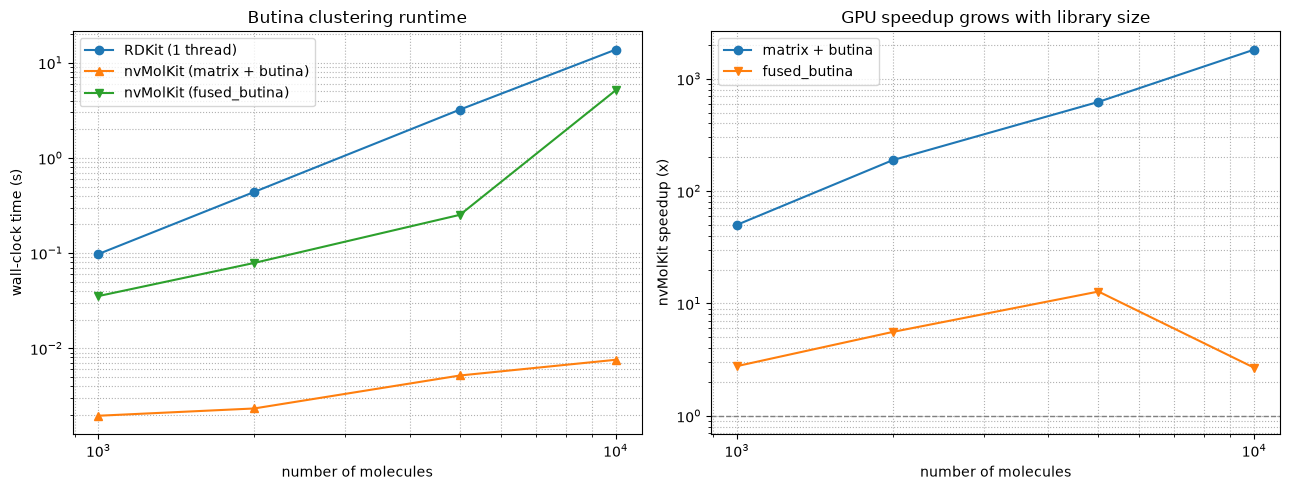

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (matrix + butina)")
ax1.plot(df["n_mols"], df["nvmolkit_fused_s"], "v-", label="nvMolKit (fused_butina)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title("Butina clustering runtime")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="matrix + butina")
ax2.plot(df["n_mols"], df["fused_speedup_vs_1thread"], "v-", label="fused_butina")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with library size")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Same clusters.** The GPU partitions match RDKit's closely (Adjusted Rand Index near 1.0 and near-identical
  cluster counts); small differences come from Butina's greedy tie-breaking, not from a different algorithm.
- **Matrix + `butina` is the fast path.** When the N×N distance matrix fits in GPU memory, computing it with
  `crossTanimotoSimilarity` and clustering with `butina` is orders of magnitude faster than the RDKit pipeline,
  and the speedup grows with library size (the O(n²) effect from Tutorial 2).
- **`fused_butina` is the scalable path.** It recomputes similarities on the fly and never stores the matrix, so
  it handles libraries too large to materialize N×N - at the cost of more compute per run.
- **Drop-in distance matrices.** `butina` accepts any GPU distance matrix, including the conformer RMSD / TFD
  matrices from Tutorials 7-8.

**Next:** Tutorial 10 covers substructure search.